## ==============================================================================
# Sample of my Data 100 Homework 
# AUTHOR: Joseph Jung
# CONTEXT: Shows how I approach the data analysis technical life cycle: starting from importing to ending with visualizing 
## ==============================================================================

## 1. Import Libraries

In [65]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure that pandas shows at least 280 characters in columns, so we can see full articles.
pd.set_option("max_colwidth", 280)
plt.style.use("fivethirtyeight")
sns.set()
sns.set_context("talk")
sns.set_palette("colorblind")

## 2. Data Loading

In [66]:
#Primary dataset that we will perform majority of preprocessing happens
news_df = pd.read_json('data/nyt_articles.txt')
news_df.head(3)

,web_url,pub_date,lead_paragraph
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do."
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne..."


In [67]:
#Second pre-made dataset for further analysis
sentiment = pd.read_csv("data/nyt_sentiments.csv")

## 3. Using regular expression to transform data into usable columns

In [68]:
pattern = r"([0-9]{4})-([0-9]{2})-[0-9]{2}T[0-9]{2}:([0-9]{2}):[0-9]{2}\+[0-9]{4}"
dates = (
    news_df["pub_date"]
    .str.extract(pattern)
    .rename(columns={0:"Year", 1:"Month", 2:"Minute"}).astype(int)
) 

dates.head()

,Year,Month,Minute
0,2020,1,0
1,2020,1,42
2,2020,1,0
3,2020,1,40
4,2020,1,20


In [69]:
news_df_dates = news_df.merge(right=dates, left_index=True, right_index=True)
news_df_dates.head(3)

,web_url,pub_date,lead_paragraph,Year,Month,Minute
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.,2020,1,42
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne...",2020,1,0


In [70]:
NewYearPattern = r"\bNew Year('s)?\b"
ZoomPattern = r"\bZoom\b"
GPTPattern = r"\b[A-Za-z]+-?GPT\b"

topic_pattern_map = {
    "New Year": NewYearPattern,
    "Zoom": ZoomPattern,
    "GPT Model": GPTPattern,
}

for topic, regex_pattern in topic_pattern_map.items():
    news_df_dates[topic] = (
        news_df_dates["lead_paragraph"]
        .str.findall(regex_pattern)
        .str.len()
    )

news_df_dates.head(1)

,web_url,pub_date,lead_paragraph,Year,Month,Minute,New Year,Zoom,GPT Model
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0,1,0,0


## More data transformation

In [71]:
quarter_num = (news_df_dates["Month"] - 1) // 3 + 1
news_df_dates['Quarter'] = news_df_dates["Year"].astype(str) + "Q" + quarter_num.astype(str)
news_df_dates.head(3)

,web_url,pub_date,lead_paragraph,Year,Month,Minute,New Year,Zoom,GPT Model,Quarter
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0,1,0,0,2020Q1
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.,2020,1,42,1,0,0,2020Q1
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne...",2020,1,0,1,0,0,2020Q1


## 4. Data Manipulation and Visualization

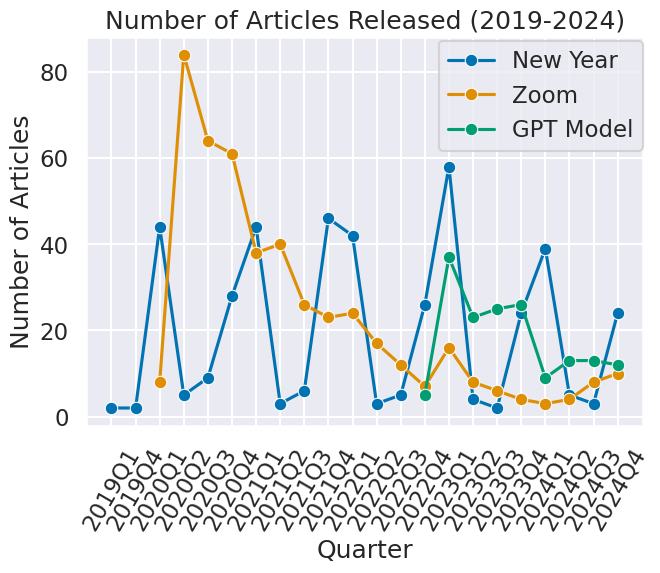

In [72]:
#count articles mentioning New Year
new_year = (
    news_df_dates[news_df_dates["New Year"] > 0]
    .groupby("Quarter")
    .size()
    .reset_index(name="Number of Articles")
)
new_year["Topic"] = "New Year"

#count articles mentioning Zoom
zoom = (
    news_df_dates[news_df_dates["Zoom"] > 0]
    .groupby("Quarter")
    .size()
    .reset_index(name="Number of Articles")
)
zoom["Topic"] = "Zoom"

#count articles mentioning GPT Model
gpt = (
    news_df_dates[news_df_dates["GPT Model"] > 0]
    .groupby("Quarter")
    .size()
    .reset_index(name="Number of Articles")
)
gpt["Topic"] = "GPT Model"

#combine the three datasets
plot_df = pd.concat([new_year, zoom, gpt], ignore_index=True)

# visualize grouped line plot
sns.lineplot(
    data=plot_df,
    x="Quarter",
    y="Number of Articles",
    hue="Topic",
    marker="o"
)

plt.xticks(rotation=60)
plt.yticks()
plt.ylabel("Number of Articles")
plt.xlabel("Quarter")
plt.title("Number of Articles Released (2019-2024)")
plt.gcf().set_facecolor('white')
plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1.02))
plt.show()

## Transforming and filtering the second dataset

In [73]:
sentiment = pd.read_csv("data/nyt_sentiments.csv")

sentiment["article_sentiment"] = (
    (2*(sentiment["label"] == "POSITIVE") - 1) * sentiment["score"]
)
news_df_sentiment2 = news_df_dates.merge(sentiment, on="web_url")
news_df_sentiment = news_df_sentiment2.drop(columns=["label", "score"])
news_df_sentiment.head(3)

,web_url,pub_date,lead_paragraph,Year,Month,Minute,New Year,Zoom,GPT Model,Quarter,article_sentiment
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0,1,0,0,2020Q1,0.986820
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.,2020,1,42,1,0,0,2020Q1,-0.992706
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne...",2020,1,0,1,0,0,2020Q1,-0.997801


In [74]:
news_df_filtered = news_df_sentiment[((news_df_sentiment['Zoom'] > 0) | news_df_sentiment['New Year'] > 0) | (news_df_sentiment['GPT Model'] > 0)]

In [75]:
news_df_filtered2 = news_df_filtered[['lead_paragraph', 'article_sentiment']]

top_positive = news_df_filtered2.sort_values(by = "article_sentiment", ascending = False).head(5).reset_index(drop = True)
top_negative = news_df_filtered2.sort_values(by = "article_sentiment", ascending = True).head(5).reset_index(drop = True)

display(top_positive, top_negative)

,lead_paragraph,article_sentiment
0,"Happy New Year, audiophiles!",0.999876
1,"It’s easy to think about Twyla Tharp and immediately picture her body of work. It’s impressive. Tharp has choreographed more than 150 dances for just about every surface and site imaginable: the concert stage, parks, Broadway, film, ice and now Zoom.",0.999872
2,"Merry Christmas, happy Hanukkah, joyous Kwanzaa and happy New Year.",0.999871
3,"Merry Christmas, happy Hanukkah, joyous Kwanzaa and happy New Year.",0.999871
4,Happy New Year!,0.999869


,lead_paragraph,article_sentiment
0,"The day after Labor Day has got to be one of the worst days in the American calendar year. (Not quite as bad as the first workday after New Year’s, but worth mentioning in the same breath.)",-0.999777
1,"One day this quarantine, who can say which, I encountered the following pieces of information: Zoom, the videoconferencing company, saw its stock hit a new high; Zūm, a ride-sharing venture, cut its work force by a third; and Zume, the robot pizza start-up, failed to raise mo...",-0.999759
2,"In the beginning there was Covid-19, and the tribe of the white collars rent their garments, for their workdays were a formless void, and all their rituals were gone. New routines came to replace the old, but the routines were scattered, and there was chaos around how best to...",-0.999729
3,"There’s a problem with leading artificial intelligence tools like ChatGPT, Gemini and Claude: We don’t really know how smart they are.",-0.999702
4,"I was in Brooklyn on a Zoom meeting in mid-March, when I saw my mom’s name come up on my cellphone. ""Your dad’s not feeling well,"" she said.",-0.999698


## Visualizing the second dataset

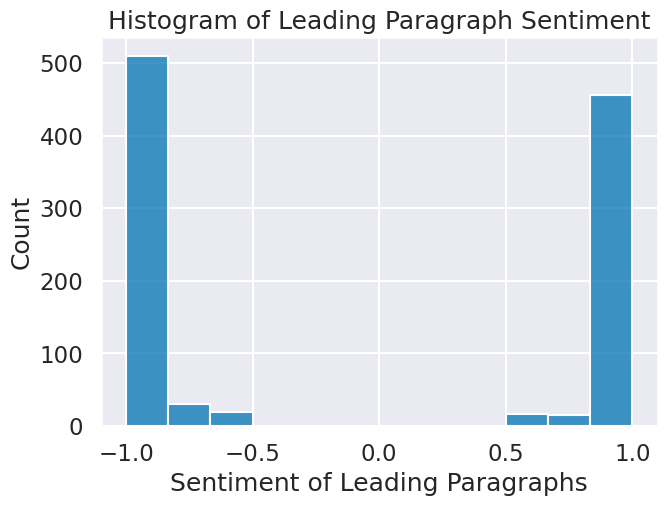

In [76]:
sns.histplot(data=news_df_filtered, x='article_sentiment')
plt.xlabel('Sentiment of Leading Paragraphs')
plt.title('Histogram of Leading Paragraph Sentiment')
plt.plot();

## Manipulating and visualizing second dataset

Text(0.5, 1.0, 'Greater % of Negative Sentiment Articles for Platform Topics')

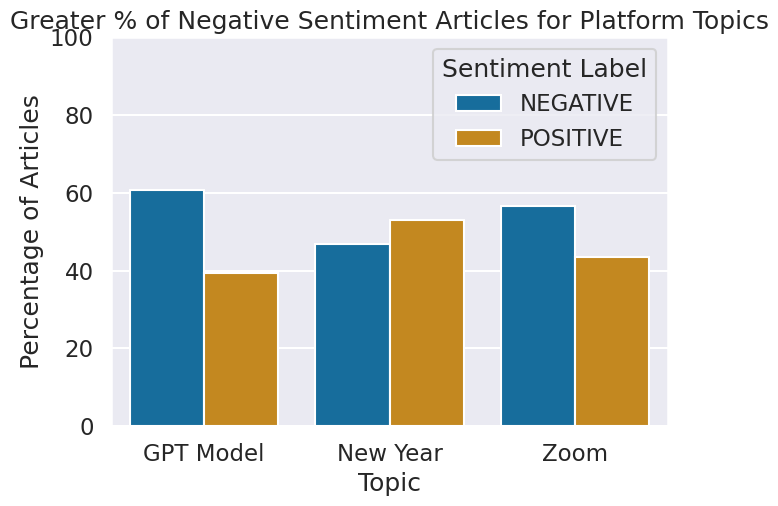

In [77]:
news_df_sentiment2 = news_df_sentiment2.rename(columns={"label": "Sentiment Label"})

#Transform new year, zoom, and gpt columns into a single column 'topic' 
sent_compare_df = (
    news_df_sentiment2
    .melt(
        id_vars=["web_url", "Quarter"],
        value_vars=["New Year", "Zoom", "GPT Model"],
        var_name="Topic",
        value_name="Count"
    )
    .query("Count > 0")
)
sent_compare_df

sent_compare_df = sent_compare_df[['web_url', 'Topic']]


#Merge with raw data
news_df_sentiment3 = news_df_sentiment2.merge(
    sent_compare_df,
    on=["web_url"],
    how="inner"
)

#group by sentiment label and topic
news_df_sentiment3 = news_df_sentiment3[['Sentiment Label', 'Topic']]
news_df_sentiment3 = news_df_sentiment3.groupby(['Sentiment Label', 'Topic']).size().reset_index(name='Count')

#find percentage of articles for each combination of label and topic
news_df_sentiment3["Percentage of Articles"] = (
    news_df_sentiment3["Count"]
    / news_df_sentiment3.groupby("Topic")["Count"].transform("sum")
    * 100
)

#visualize grouped bar plots
sns.barplot(
    data=news_df_sentiment3,
    x="Topic",
    y="Percentage of Articles",
    hue="Sentiment Label")

plt.ylim(0,100)
plt.title("Greater % of Negative Sentiment Articles for Platform Topics")